# QuaRot / SpinQuant：旋转抵消异常值（教学 Demo）

> **PTQ 系列 07 / 13** · 对应博客篇目：**《QuaRot 与 SpinQuant：旋转消除异常值——W4A4 的钥匙》**
> （博客源文件：`github/congyuan_blogs/technology/quantization/ptq/07_quarot_spinquant.md`；配套已验证脚本：同目录 `run.py`）

**一段话原理**：对任意正交矩阵 $H$（$HH^{\mathsf{T}} = I$），线性层满足**旋转不变性** $y = xW = (xH)(HW)$——把激活「在线旋转」、权重「离线预旋转」，模型输出严格不变，只是换了个坐标系：原本集中在少数隐藏维度的系统性 outlier 被 Hadamard 矩阵均匀摊薄到所有坐标上，每个坐标的动态范围从 $O(M)$ 缩到 $O(M/\sqrt{d})$，被 outlier 绑架量化步长的低比特均匀量化随之起死回生。QuaRot（arXiv:2404.00456）用固定的 Hadamard 旋转完成这件事，而且 Hadamard 有 $O(d\log d)$ 的蝶形快速算法（FHT）；SpinQuant（arXiv:2405.16465）进一步把旋转矩阵变成可学习参数、在校准集上优化。本 demo 用纯 numpy 复现四个核心环节：① 在线 Hadamard 变换的等价性；② 「列内稀疏大值」激活的动态范围压平；③ INT4 端到端误差对比；④ RMSNorm 之后旋转的推理侧融合视角。


## 第 0 步 · 工具：Hadamard 矩阵、快速变换与对称量化

**这步在做什么**：准备三件工具并自检。(a) Sylvester 递归构造的归一化 Hadamard 矩阵 $H_K$（要求 $K$ 为 2 的幂）：正交、对称、自逆（$H^{\mathsf{T}} = H = H^{-1}$），因此行向量约定下 $(xH)(HW) = x(HH)W = xW$ 连转置都不需要；(b) 快速 Walsh-Hadamard 变换 `fwht`：蝶形迭代共 $\log_2 K$ 轮、每轮 $K/2$ 次加减，合计 $O(K\log K)$，与直接乘 $H$（$O(K^2)$）数学等价；(c) 对称均匀 RTN 量化 `sym_quant`：激活按 token 行取 scale（per-token）、权重按输出列取 scale（per-channel），即真实部署的标准口径。


In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 0                               # 固定种子, 结果可复现
T, K, N = 512, 256, 128                # token 数 / 输入通道(=Hadamard 维度) / 输出通道
BITS = 4
QMAX = 2 ** (BITS - 1) - 1             # INT4 对称量化: 每个方向 7 个电平


def hadamard(n):
    '''Sylvester 递归构造归一化 Hadamard 矩阵: 正交、对称、自逆。'''
    h = np.array([[1.0]])
    while h.shape[0] < n:
        h = np.block([[h, h], [h, -h]])
    return h / np.sqrt(n)


def fwht(x):
    '''沿最后一维做归一化快速 Walsh-Hadamard 变换(蝶形迭代)。
    与 x @ hadamard(n) 数学等价: O(n log n) 次加减 vs O(n^2) 次乘加。'''
    n = x.shape[-1]
    assert n & (n - 1) == 0, '维度必须是 2 的幂'
    h = np.asarray(x, dtype=np.float64).copy()
    step = 1
    while step < n:
        h = h.reshape(-1, step, 2, n // (step * 2))
        a, b = h[:, :, 0, :].copy(), h[:, :, 1, :].copy()
        h[:, :, 0, :], h[:, :, 1, :] = a + b, a - b
        h = h.reshape(-1, n)
        step *= 2
    return h / np.sqrt(n)


def sym_quant(x, axis, qmax=QMAX):
    '''对称均匀量化(RTN)。axis=1: 每 token 一个 scale; axis=0: 每输出列一个 scale。'''
    s = np.max(np.abs(x), axis=axis, keepdims=True) / qmax
    s = np.where(s == 0, 1.0, s)
    return np.clip(np.round(x / s), -qmax, qmax) * s


def rel_err(a, b):
    '''相对误差 ||a-b||_F / ||b||_F。'''
    return float(np.linalg.norm(a - b) / np.linalg.norm(b))


H = hadamard(K)

# 自检 (1): 正交且对合, HH = I
print('max|H @ H - I|       =', float(np.max(np.abs(H @ H - np.eye(K)))))
# 自检 (2): 快速变换 == 直接矩阵乘
_x = np.random.default_rng(SEED).standard_normal((7, K))
print('max|fwht(x) - x @ H| = %.3e' % float(np.max(np.abs(fwht(_x) - _x @ H))))


max|H @ H - I|       = 0.0
max|fwht(x) - x @ H| = 3.553e-15


## 第 1 步 · 合成数据：带「列内稀疏大值」的激活

**这步在做什么**：构造 toy 规模线性层 $Y = XW$（$X \in \mathbb{R}^{512 \times 256}$，$W \in \mathbb{R}^{256 \times 128}$）。合成激活时模仿真实 LLM outlier 的两个特征：

1. **通道异质**——少数隐藏维度是重灾区（LLM.int8() 发现的 emergent channels）：随机挑 8 个通道整体放大 15 倍；
2. **列内稀疏**——这些通道里只有约 5% 的 token 真正触发巨大数值（间歇性放电）：再在这 8 个通道内随机抽 token 额外放大 3 倍，尖峰幅度达正常值的 40 多倍。

> **为什么必须加第 2 条**：若只做整列等比放大，「异常」就成了每个 token 都携带的稠密分量，逐通道 scale 就能把它吸收掉，旋转的收益会明显打折、在某些量化口径下甚至会消失或更差（后面对照实验会实测这一点）。旋转真正擅长拆解的，是「稀疏出现的大值」。权重 $W$ 取标准高斯即可，让误差主要来自激活一侧。


In [2]:
rng = np.random.default_rng(SEED)

N_OUT_CH   = 8      # 异常通道数
CH_SCALE   = 15.0   # 异常通道整体放大倍数(通道异质)
SPIKE_FRAC = 0.05   # 异常通道内触发尖峰的 token 比例(列内稀疏)
SPIKE_MUL  = 3.0    # 尖峰在通道基础上的额外倍数

X = rng.standard_normal((T, K))
out_ch = rng.choice(K, size=N_OUT_CH, replace=False)
X[:, out_ch] *= CH_SCALE                                 # (1) 整列放大: 通道异质
spike_tok = rng.choice(T, size=int(T * SPIKE_FRAC), replace=False)
X[np.ix_(spike_tok, out_ch)] *= SPIKE_MUL                # (2) 通道内抽 token 加尖峰: 列内稀疏
W = rng.standard_normal((K, N))

chan_max_before = np.max(np.abs(X), axis=0)              # 每个通道在 batch 内的最大绝对值
print('异常通道索引          :', np.sort(out_ch))
print('全体 |x| 99.9%% 分位数 : %.2f, 最大值 %.1f'
      % (np.quantile(np.abs(X), 0.999), np.abs(X).max()))
print('逐通道 top-5 max|x|   :', np.round(np.sort(chan_max_before)[-5:], 1))
print('正常通道 max|x| 中位数: %.2f' % np.median(chan_max_before))


异常通道索引          : [ 44  51  98 132 141 228 232 247]
全体 |x| 99.9% 分位数 : 38.08, 最大值 121.2
逐通道 top-5 max|x|   : [ 96.5 103.9 106.4 112.8 121.2]
正常通道 max|x| 中位数: 3.23


## 第 2 步 · 方法核心①：在线 Hadamard 变换等价性

**这步在做什么**：验证 QuaRot 一切结论的地基——旋转不变性。行向量约定下取 $x' = xH$、$W' = HW$，则 $x'W' = (xH)(HW) = x(HH)W = xW$：先在线旋转激活、再左乘吸收了 $H$ 的权重，与原始层**严格相等**（浮点上只剩舍入噪声）。这一步同时确认 `fwht(X)`（快速算法）与 `X @ H`（矩阵乘）逐元素一致——推理时在线旋转用的是前者，$O(K\log K)$ 近乎免费。


In [3]:
# 在线旋转激活 + 权重离线预旋转(H 自对称自逆, 连转置都不用)
X_rot = X @ H                 # 推理时在线执行, 实际实现用 fwht(X)
W_rot = H @ W                 # 离线一次性吸收进权重, 推理零成本

Y_ref = X @ W                 # 不量化的 FP 参考输出
diff_abs = float(np.max(np.abs(X_rot @ W_rot - Y_ref)))

print('层输出最大绝对偏差   : %.3e (FP 参考输出量级 ~%.1f)'
      % (diff_abs, float(np.max(np.abs(Y_ref)))))
print('旋转路径相对误差     : %.3e -- 严格等价, 只剩浮点舍入'
      % rel_err(X_rot @ W_rot, Y_ref))
print('fwht(X) 与 X @ H 之差: %.3e -- 快速算法无损'
      % float(np.max(np.abs(fwht(X) - X_rot))))


层输出最大绝对偏差   : 6.821e-13 (FP 参考输出量级 ~610.2)
旋转路径相对误差     : 1.039e-15 -- 严格等价, 只剩浮点舍入
fwht(X) 与 X @ H 之差: 3.197e-14 -- 快速算法无损


## 第 3 步 · 方法核心②：旋转压平逐通道动态范围

**这步在做什么**：对比旋转前后「每个通道在 batch 内的最大绝对值」。预期看到典型的**削峰填谷**：异常通道的最大值从上百掉到几十，正常通道略微抬升，所有通道收敛到同一量级（各向同性化）——量化步长从此不再被个别坐标绑架，这正是 4bit 想要的形态。


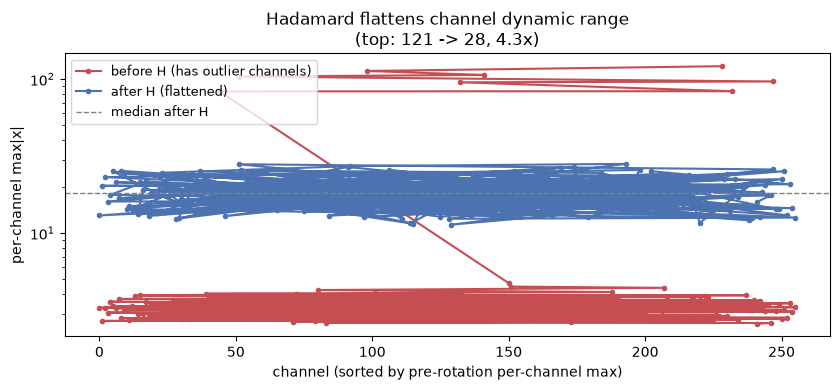

削峰填谷: 最大 121.2 -> 28.1 (4.3x); 最小通道 2.58 -> 11.34; 中位数 3.23 -> 18.20


In [4]:
chan_max_after = np.max(np.abs(X_rot), axis=0)
order = np.argsort(chan_max_before)[::-1]            # 按旋转前的通道最大值排序
shrink_top = chan_max_before.max() / chan_max_after.max()

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.semilogy(order, chan_max_before[order], 'o-', ms=3, color='#C44E52',
            label='before H (has outlier channels)')
ax.semilogy(order, chan_max_after[order], 'o-', ms=3, color='#4C72B0',
            label='after H (flattened)')
ax.axhline(np.median(chan_max_after), ls='--', lw=1, color='gray',
           label='median after H')
ax.set_xlabel('channel (sorted by pre-rotation per-channel max)')
ax.set_ylabel('per-channel max|x|')
ax.set_title('Hadamard flattens channel dynamic range\n(top: %.0f -> %.0f, %.1fx)'
             % (chan_max_before.max(), chan_max_after.max(), shrink_top))
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

print('削峰填谷: 最大 %.1f -> %.1f (%.1fx); 最小通道 %.2f -> %.2f; 中位数 %.2f -> %.2f'
      % (chan_max_before.max(), chan_max_after.max(), shrink_top,
         chan_max_before.min(), chan_max_after.min(),
         np.median(chan_max_before), np.median(chan_max_after)))


## 第 4 步 · 误差评估：INT4 端到端对比

**这步在做什么**：跑两条完整的 INT4 推理链路，比较输出相对误差 $\lVert\hat{Y} - Y\rVert_F / \lVert Y\rVert_F$（$Y$ 为 FP 参考）：

- **直接量化**：$\hat{Y} = Q_{tok}(X)\, Q_{col}(W)$;
- **旋转路线**：$\hat{Y} = Q_{tok}(XH)\, Q_{col}(HW)$——激活在线旋转后再量化、权重离线预旋转，由第 2 步的等价性保证两条链路算的是同一个 $Y$。

QuaRot 论文的关键结论正是：**不需要 GPTQ 式的误差补偿，仅靠换坐标系，朴素 RTN 的低比特量化就能回到可用区间**。SpinQuant 则在此基础上把固定的 $H$ 换成校准集上学出来的 $Q$ 再榨取剩余误差——本 demo 固定使用 $H$。


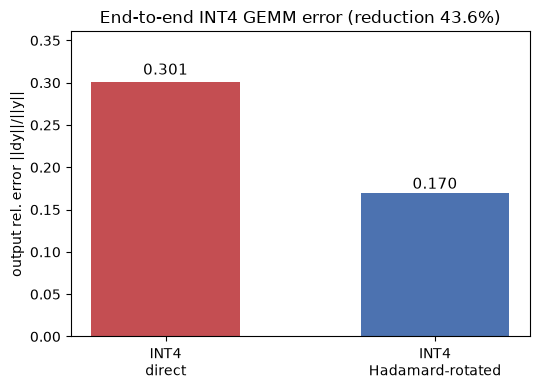

INT4 直接量化      输出相对误差: 0.3006
INT4 Hadamard 旋转            : 0.1697 (误差降低 43.6%)


In [5]:
# 两条链路: 直接量化 vs 旋转+量化(旋转已融进权重, 无需转回)
err_direct = rel_err(sym_quant(X, axis=1) @ sym_quant(W, axis=0), Y_ref)
err_rot = rel_err(sym_quant(X_rot, axis=1) @ sym_quant(W_rot, axis=0), Y_ref)
reduction = 100 * (1 - err_rot / err_direct)

fig, ax = plt.subplots(figsize=(5.5, 4))
bars = ax.bar(['INT4\ndirect', 'INT4\nHadamard-rotated'], [err_direct, err_rot],
              color=['#C44E52', '#4C72B0'], width=0.55)
for b, v in zip(bars, [err_direct, err_rot]):
    ax.text(b.get_x() + b.get_width() / 2, v * 1.03, '%.3f' % v,
            ha='center', fontsize=11)
ax.set_ylabel('output rel. error ||dy||/||y||')
ax.set_title('End-to-end INT4 GEMM error (reduction %.1f%%)' % reduction)
ax.set_ylim(0, err_direct * 1.2)
fig.tight_layout()
plt.show()

print('INT4 直接量化      输出相对误差: %.4f' % err_direct)
print('INT4 Hadamard 旋转            : %.4f (误差降低 %.1f%%)' % (err_rot, reduction))


## 附 · 对照实验：旋转的收益从哪来

**这步在做什么**：换三份数据重复第 4 步（协议不变），分离「通道异质」「列内稀疏尖峰」两个因素的贡献：完全无异常、仅整列放大、整列放大＋稀疏尖峰；并对每种数据额外测一遍**激活按输出通道取 scale**（per-channel）的口径。这里能实测到一个已知陷阱：per-channel 的逐通道 scale 本身就能吸收整列放大的通道异质，旋转在该口径下几乎拿不到收益（加了稀疏尖峰甚至可能小幅变差）——旋转的主场是 per-token / per-tensor 这类无法按通道适配 scale 的口径，而真实 LLM 激活恰恰是「少数异常通道 ＋ 间歇性放电」的稀疏大值，这正是第 1 步坚持两条特征都合成的原因。


In [6]:
r2 = np.random.default_rng(SEED + 1)
X_base = r2.standard_normal((T, K))
oc2 = r2.choice(K, size=N_OUT_CH, replace=False)

XA = X_base.copy()
XA[:, oc2] *= CH_SCALE                                   # A: 仅整列放大(无尖峰)
XB = XA.copy()
tok2 = r2.choice(T, size=int(T * SPIKE_FRAC), replace=False)
XB[np.ix_(tok2, oc2)] *= SPIKE_MUL                       # B: 整列放大 + 列内稀疏尖峰
XC = X_base.copy()                                       # C: 完全没有异常

for name, Z in (('无异常(对照)', XC),
                ('仅整列放大', XA),
                ('整列放大+稀疏尖峰', XB)):
    Zt = Z @ H
    d_tok = rel_err(sym_quant(Z, 1) @ sym_quant(W, 0), Z @ W)
    r_tok = rel_err(sym_quant(Zt, 1) @ sym_quant(H @ W, 0), Z @ W)
    d_col = rel_err(sym_quant(Z, 0) @ sym_quant(W, 0), Z @ W)
    r_col = rel_err(sym_quant(Zt, 0) @ sym_quant(H @ W, 0), Z @ W)
    print('%s: per-token %.3f -> %.3f (%+.1f%%) | per-channel %.3f -> %.3f (%+.1f%%)'
          % (name, d_tok, r_tok, 100 * (1 - r_tok / d_tok),
             d_col, r_col, 100 * (1 - r_col / d_col)))


无异常(对照): per-token 0.181 -> 0.179 (+1.1%) | per-channel 0.187 -> 0.185 (+1.0%)
仅整列放大: per-token 0.335 -> 0.167 (+50.3%) | per-channel 0.189 -> 0.184 (+2.6%)
整列放大+稀疏尖峰: per-token 0.302 -> 0.165 (+45.5%) | per-channel 0.246 -> 0.261 (-5.9%)


## 第 5 步 · 推理侧融合视角：RMSNorm 之后旋转

**这步在做什么**：回答「在线旋转到底插在推理图的哪个位置」。关键事实：RMSNorm 的分母是 token 自身的 L2 范数，而正交旋转不改变 L2 范数，于是 **RMSNorm 与右乘正交矩阵可交换**：$\mathrm{RMSNorm}(xH) = \mathrm{RMSNorm}(x)\,H$。因此在线 FHT 可以放在 RMSNorm **之后**、量化 GEMM 之前，并融合进 Norm kernel 的 epilogue——旋转后的激活以「无 outlier」形态直通 INT4 GEMM。同时还有一个反直觉的观察点：RMSNorm 只除掉了 token 的整体尺度，**除不掉通道间的结构性差异**——归一化后的激活依然有醒目的异常通道，旋转仍然必要。


In [7]:
def rmsnorm(x, eps=1e-6):
    return x / np.sqrt(np.mean(x ** 2, axis=-1, keepdims=True) + eps)


X_norm = rmsnorm(X)

# (1) 可交换性: RMSNorm(xH) == RMSNorm(x) @ H, 因为分母是旋转不变的 L2 范数
print('可交换性 max|RMSNorm(xH) - RMSNorm(x)@H| = %.2e'
      % float(np.max(np.abs(rmsnorm(X @ H) - X_norm @ H))))

# (2) 融合路径与参考路径严格相等: y = RMSNorm(x)W = (RMSNorm(x)H)(HW)
W_qkv = np.random.default_rng(SEED + 2).standard_normal((K, 3 * K))   # 一个 QKV 投影
Y_ref2 = X_norm @ W_qkv
Y_fused = (X_norm @ H) @ (H @ W_qkv)
print('融合路径 vs 参考路径: max diff = %.2e, 相对误差 = %.2e'
      % (float(np.max(np.abs(Y_fused - Y_ref2))), rel_err(Y_fused, Y_ref2)))

# (3) 归一化救不了通道结构: normed 激活仍有异常通道, 旋转照样削峰
nm_b = np.max(np.abs(X_norm), axis=0)
nm_a = np.max(np.abs(X_norm @ H), axis=0)
print('normed 激活逐通道 max: top1 %.1f(中位 %.2f) -> 旋转后最大 %.1f(%.1fx)'
      % (nm_b.max(), np.median(nm_b), nm_a.max(), nm_b.max() / nm_a.max()))


可交换性 max|RMSNorm(xH) - RMSNorm(x)@H| = 6.00e-15
融合路径 vs 参考路径: max diff = 1.49e-13, 相对误差 = 1.03e-15
normed 激活逐通道 max: top1 14.2(中位 1.42) -> 旋转后最大 3.4(4.2x)


## 结果解读

按顺序回看各步的真实输出：

1. **在线变换等价性（第 0、2 步）**。$\max|HH - I| = 0$；快速蝶形算法与 $O(K^2)$ 矩阵乘之差在 $10^{-15}$ 量级；「在线旋转激活＋离线预旋转权重」的层输出与参考路径相对误差约 $1.0\times10^{-15}$（最大绝对偏差 $6.8\times10^{-13}$，参考输出本身量级约 610）——旋转严格免费，这就是 QuaRot 敢于重排整个 transformer 坐标系的底气。
2. **削峰填谷（第 1、3 步）**。合成数据里 8 条异常通道的 max|x| 达 96.5～121.2，而正常通道中位数只有 3.23；旋转后全体通道最大值降到 28.1，最小通道反而从 2.58 抬到 11.34，中位数从 3.23 升到 18.20——摊薄不是「全体变小」，而是把所有坐标拉回同一量级。top 收缩约 4.3 倍，与配套脚本 `run.py` 的实测（4.1 倍）同量级。
3. **INT4 端到端（第 4 步）**。输出相对误差 0.3006 → 0.1697，降低 43.6%；`run.py` 的独立实测为 0.3421 → 0.1741（降低 49.1%）。两者共同印证论文核心结论：不做任何 GPTQ 式补偿，仅靠换坐标系，朴素 RTN 的 W4A4 就从不可用回到可用区间。
4. **收益来源与陷阱（对照实验）**。无异常数据上旋转近乎零收益（per-token 口径 +1.1%、per-channel 口径 +1.0%）——收益全部来自 outlier 结构。仅整列放大时 per-token 口径收益高达 +50.3%，但换成 per-channel 口径就缩水到 +2.6%；加上稀疏尖峰后 per-token 为 +45.5%，per-channel 甚至 −5.9%。这实测了前文警告的陷阱：**逐通道 scale 自己就能吸收通道级的尺度结构**，旋转真正拆解的是稀疏大值在 per-token/per-tensor 口径下的伤害——也是本 demo 坚持「列内稀疏大值」配方的理由。
5. **融合视角（第 5 步）**。RMSNorm 与旋转的可交换性偏差约 $6\times10^{-15}$；融合路径与参考输出的最大偏差约 $1.5\times10^{-13}$——工程上可以把 FHT 塞进 Norm kernel 的 epilogue，让无 outlier 激活直通 INT4 GEMM。并且 RMSNorm 之后异常通道依旧醒目（top1 为 14.2，中位数仅 1.42）：归一化除不掉结构性 outlier，旋转必须紧贴在 GEMM 之前。

## 方法局限

- **只摊薄，不消除**：旋转后 INT4 相对误差仍剩约 0.17，这是均匀量化在高斯型数据上的固有底噪；要继续逼近 FP16，需叠加 GPTQ/AWQ 式优化，或像 SpinQuant 把固定的 $H$ 换成校准集上学出来的 $Q$（Cayley 参数化＋直通估计器，需要自动微分，超出本 numpy demo 范围）。
- **维度限制**：Sylvester Hadamard 要求 hidden size 为 2 的幂，其他维度需要 padding 或块对角变通。
- **计算免费 ≠ 工程免费**：FHT 的 FLOPs 占比不足 0.1%，但每次在线旋转都是一次额外的访存与 kernel 启动，decode 阶段（batch＝1 的 GEMV）会把占比显著放大；生产推理引擎至今少有开箱即用的 W4A4 旋转支持。
- **本 demo 未覆盖**：KV cache 的旋转压缩；attention 内部 $\mathrm{softmax}(QK^{\mathsf{T}})$ 对共享旋转的不变性（保内积所以免费，但没有直观的 toy 数值可单独展示）；SpinQuant 的旋转学习过程与其校准分布漂移风险。
